#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

### Chapter 23
**CH 23 IMPORT DEMAND AND PRODUCTION**

using the asia-industry dataset

version 1.0 2021-05-05

In [1]:
import os
import sys
import warnings
from datetime import datetime as dt

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from mizani.formatters import date_format
from plotnine import *
from stargazer.stargazer import Stargazer

warnings.filterwarnings("ignore")


In [2]:
# Current script folder
current_path = os.getcwd()
dirname = current_path.split("da_case_studies")[0]

# location folders
data_in = dirname + "da_data_repo/asia-industry/clean/"
data_out = dirname + "da_case_studies/ch23-import-demand-and-production/"
output = dirname + "da_case_studies/ch23-import-demand-and-production/output/"

func = dirname + "da_case_studies/ch00-tech-prep/"
sys.path.append(func)


In [13]:
# import data
raw = pd.read_csv("/workspaces/codespaces-jupyter/data/asia-industry_tidy.csv")
raw


,time,year,month,country,countrycode,cpi_sa,cpi_yoy_nsa,exchange_rate_neer,exchange_rate_reer,exchnage_rate_vs_usd,ind_prod_const,ind_prod_const_sa,usa_imp_sa
0,1991-01,1991,1,Brunei,BRN,79.046012,2.760941,NaN,NaN,1.733090,NaN,NaN,41282.200000
1,1991-01,1991,1,Myanmar,MMR,2.085514,33.006715,NaN,NaN,6.047600,NaN,NaN,41282.200000
2,1991-01,1991,1,Philippines,PHL,30.586771,18.526728,140.464473,77.084801,27.490406,3.208372e+09,3.169451e+09,41282.200000
3,1991-01,1991,1,Malaysia,MYS,58.278131,3.635071,110.204401,108.005458,2.713870,2.754107e+09,2.748642e+09,41282.200000
4,1991-01,1991,1,Singapore,SGP,74.820077,3.607021,75.074206,89.932094,1.745174,1.690851e+09,1.667727e+09,41282.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4924,2018-06,2018,6,Taiwan China,TWN,NaN,NaN,112.720086,104.042817,29.959469,NaN,NaN,209964.487335
4925,2018-06,2018,6,Thailand,THA,NaN,NaN,110.694232,105.295867,32.316969,NaN,NaN,209964.487335
4926,2018-06,2018,6,Brunei,BRN,NaN,NaN,NaN,NaN,1.336906,NaN,NaN,209964.487335
4927,2018-06,2018,6,United States,USA,NaN,NaN,119.066857,112.391138,1.000000,NaN,NaN,209964.487335


In [15]:
data = raw.loc[lambda x: x["year"] >= 1998]

In [16]:
data = data.drop(data.loc[lambda x: (x["year"] == 1998) & (x["month"] == 1)].index)
data = data.drop(data.loc[lambda x: (x["year"] == 2018) & (x["month"] > 4)].index)

In [17]:
data.groupby("countrycode").agg(
    mean=("ind_prod_const", "mean"),
    std_dev=("ind_prod_const", "first"),
    freq=("ind_prod_const", "count"),
).dropna().reset_index().sort_values(by="countrycode")


,countrycode,mean,std_dev,freq
0,CHN,2.046815e+11,4.956969e+10,243
1,IDN,2.729169e+10,1.591749e+10,243
2,MYS,8.150858e+09,4.526050e+09,243
3,PHL,7.193672e+09,6.599710e+09,243
4,SGP,4.840317e+09,2.324321e+09,243
5,THA,9.791123e+09,5.602920e+09,243
6,TWN,1.171419e+10,6.744322e+09,242
7,USA,2.640678e+11,2.344603e+11,243


In [10]:
# feature engineering

In [18]:
data = data.merge(
    data.groupby("time")
    .apply(
        lambda x: max(np.where(x["countrycode"] == "USA", x["ind_prod_const_sa"], 0))
    )
    .reset_index()
    .rename(columns={0: "usa_ip_sa"}),
    on="time",
)

In [19]:
data

,time,year,month,country,countrycode,cpi_sa,cpi_yoy_nsa,exchange_rate_neer,exchange_rate_reer,exchnage_rate_vs_usd,ind_prod_const,ind_prod_const_sa,usa_imp_sa,usa_ip_sa
0,1998-02,1998,2,China,CHN,83.682182,-0.187553,93.494761,100.341122,8.279300,4.956969e+10,5.045212e+10,74184.000000,2.332954e+11
1,1998-02,1998,2,Myanmar,MMR,11.155840,45.218180,NaN,NaN,6.366300,NaN,NaN,74184.000000,2.332954e+11
2,1998-02,1998,2,Brunei,BRN,93.891453,-0.302440,NaN,NaN,1.666550,NaN,NaN,74184.000000,2.332954e+11
3,1998-02,1998,2,Malaysia,MYS,76.090230,4.415547,98.532484,95.946542,3.826650,4.526050e+09,4.769493e+09,74184.000000,2.332954e+11
4,1998-02,1998,2,Taiwan China,TWN,89.286853,0.514477,112.054959,127.695750,32.728800,6.744322e+09,7.863413e+09,74184.000000,2.332954e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3626,2018-04,2018,4,Lao PDR,LAO,134.479590,1.925363,NaN,NaN,NaN,NaN,NaN,208953.556838,2.888097e+11
3627,2018-04,2018,4,Singapore,SGP,115.989924,0.072107,110.817367,106.349081,1.315944,7.451268e+09,7.320880e+09,208953.556838,2.888097e+11
3628,2018-04,2018,4,Papua New Guinea,PNG,NaN,NaN,NaN,NaN,3.246753,NaN,NaN,208953.556838,2.888097e+11
3629,2018-04,2018,4,Taiwan China,TWN,108.970135,1.827391,112.238725,103.732393,29.378476,NaN,NaN,208953.556838,2.888097e+11


In [20]:
data = data.merge(
    data.groupby("time")
    .apply(
        lambda x: max(np.where(x["countrycode"] == "CHN", x["ind_prod_const_sa"], 0))
    )
    .reset_index()
    .rename(columns={0: "chn_ip_sa"}),
    on="time",
)

In [21]:
data["ln_ip"] = np.log(data["ind_prod_const_sa"] + 1)
data["ln_usa_ip"] = np.log(data["usa_ip_sa"] + 1)
data["ln_chn_ip"] = np.log(data["chn_ip_sa"] + 1)
data["ln_usa_imports"] = np.log(data["usa_imp_sa"] + 1)
data["ln_er_usd"] = np.log(data["exchnage_rate_vs_usd"] + 1)

In [22]:
data

,time,year,month,country,countrycode,cpi_sa,cpi_yoy_nsa,exchange_rate_neer,exchange_rate_reer,exchnage_rate_vs_usd,ind_prod_const,ind_prod_const_sa,usa_imp_sa,usa_ip_sa,chn_ip_sa,ln_ip,ln_usa_ip,ln_chn_ip,ln_usa_imports,ln_er_usd
0,1998-02,1998,2,China,CHN,83.682182,-0.187553,93.494761,100.341122,8.279300,4.956969e+10,5.045212e+10,74184.000000,2.332954e+11,5.045212e+10,24.644291,26.175571,24.644291,11.214317,2.227786
1,1998-02,1998,2,Myanmar,MMR,11.155840,45.218180,NaN,NaN,6.366300,NaN,NaN,74184.000000,2.332954e+11,5.045212e+10,NaN,26.175571,24.644291,11.214317,1.996916
2,1998-02,1998,2,Brunei,BRN,93.891453,-0.302440,NaN,NaN,1.666550,NaN,NaN,74184.000000,2.332954e+11,5.045212e+10,NaN,26.175571,24.644291,11.214317,0.980786
3,1998-02,1998,2,Malaysia,MYS,76.090230,4.415547,98.532484,95.946542,3.826650,4.526050e+09,4.769493e+09,74184.000000,2.332954e+11,5.045212e+10,22.285506,26.175571,24.644291,11.214317,1.574153
4,1998-02,1998,2,Taiwan China,TWN,89.286853,0.514477,112.054959,127.695750,32.728800,6.744322e+09,7.863413e+09,74184.000000,2.332954e+11,5.045212e+10,22.785487,26.175571,24.644291,11.214317,3.518352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3626,2018-04,2018,4,Lao PDR,LAO,134.479590,1.925363,NaN,NaN,NaN,NaN,NaN,208953.556838,2.888097e+11,4.678761e+11,NaN,26.389034,26.871469,12.249872,NaN
3627,2018-04,2018,4,Singapore,SGP,115.989924,0.072107,110.817367,106.349081,1.315944,7.451268e+09,7.320880e+09,208953.556838,2.888097e+11,4.678761e+11,22.713996,26.389034,26.871469,12.249872,0.839818
3628,2018-04,2018,4,Papua New Guinea,PNG,NaN,NaN,NaN,NaN,3.246753,NaN,NaN,208953.556838,2.888097e+11,4.678761e+11,NaN,26.389034,26.871469,12.249872,1.446155
3629,2018-04,2018,4,Taiwan China,TWN,108.970135,1.827391,112.238725,103.732393,29.378476,NaN,NaN,208953.556838,2.888097e+11,4.678761e+11,NaN,26.389034,26.871469,12.249872,3.413734


In [23]:
data = data.dropna(subset=["ln_ip"])
data

,time,year,month,country,countrycode,cpi_sa,cpi_yoy_nsa,exchange_rate_neer,exchange_rate_reer,exchnage_rate_vs_usd,ind_prod_const,ind_prod_const_sa,usa_imp_sa,usa_ip_sa,chn_ip_sa,ln_ip,ln_usa_ip,ln_chn_ip,ln_usa_imports,ln_er_usd
0,1998-02,1998,2,China,CHN,83.682182,-0.187553,93.494761,100.341122,8.279300,4.956969e+10,5.045212e+10,74184.000000,2.332954e+11,5.045212e+10,24.644291,26.175571,24.644291,11.214317,2.227786
3,1998-02,1998,2,Malaysia,MYS,76.090230,4.415547,98.532484,95.946542,3.826650,4.526050e+09,4.769493e+09,74184.000000,2.332954e+11,5.045212e+10,22.285506,26.175571,24.644291,11.214317,1.574153
4,1998-02,1998,2,Taiwan China,TWN,89.286853,0.514477,112.054959,127.695750,32.728800,6.744322e+09,7.863413e+09,74184.000000,2.332954e+11,5.045212e+10,22.785487,26.175571,24.644291,11.214317,3.518352
5,1998-02,1998,2,Thailand,THA,75.109905,8.775797,80.420170,76.807906,46.055000,5.602920e+09,5.439942e+09,74184.000000,2.332954e+11,5.045212e+10,22.417034,26.175571,24.644291,11.214317,3.851317
7,1998-02,1998,2,Indonesia,IDN,28.885110,30.030874,117.077511,55.594397,9049.000000,1.591749e+10,1.711103e+10,74184.000000,2.332954e+11,5.045212e+10,23.562989,26.175571,24.644291,11.214317,9.110520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3621,2018-04,2018,4,Malaysia,MYS,121.635243,1.427283,87.119863,90.495709,3.887929,1.094555e+10,1.121762e+10,208953.556838,2.888097e+11,4.678761e+11,23.140751,26.389034,26.871469,12.249872,1.586769
3622,2018-04,2018,4,Philippines,PHL,129.982280,4.508566,91.034718,99.530612,52.076095,1.175770e+10,1.146990e+10,208953.556838,2.888097e+11,4.678761e+11,23.162992,26.389034,26.871469,12.249872,3.971727
3624,2018-04,2018,4,Thailand,THA,113.056494,1.086030,111.429353,105.885040,31.313381,1.135948e+10,1.279932e+10,208953.556838,2.888097e+11,4.678761e+11,23.272658,26.389034,26.871469,12.249872,3.475481
3627,2018-04,2018,4,Singapore,SGP,115.989924,0.072107,110.817367,106.349081,1.315944,7.451268e+09,7.320880e+09,208953.556838,2.888097e+11,4.678761e+11,22.713996,26.389034,26.871469,12.249872,0.839818


In [24]:
data = data.loc[
    lambda x: (x["countrycode"] == "MYS")
    | (x["countrycode"] == "PHL")
    | (x["countrycode"] == "SGP")
    | (x["countrycode"] == "THA")
]


In [25]:
data.groupby("countrycode")["country"].count()

countrycode
MYS    243
PHL    243
SGP    243
THA    243
Name: country, dtype: int64

In [26]:
# panel setup
# encode country , gen(cc)
# sort cc time
# tsset cc time

In [27]:
data["cc"] = data["countrycode"].astype("category")

In [28]:
# lagged variables
work = data.sort_values(by=["cc", "time"])

In [29]:
work["dln_ip"] = work.groupby("cc")["ln_ip"].transform("diff")
work["dln_usa_ip"] = work.groupby("cc")["ln_usa_ip"].transform("diff")
work["dln_chn_ip"] = work.groupby("cc")["ln_chn_ip"].transform("diff")
work["dln_usa_imports"] = work.groupby("cc")["ln_usa_imports"].transform("diff")
work["dln_er_usd"] = work.groupby("cc")["ln_er_usd"].transform("diff")

In [30]:
work.groupby("countrycode").agg(mean=("dln_ip", np.nanmean))

,mean
countrycode,
MYS,0.003534
PHL,0.002520
SGP,0.004417
THA,0.003536


In [31]:
# create time variables
work["date"] = (work["year"].astype(str) + "-" + data["month"].astype(str)).apply(
    lambda x: dt.strptime(x, "%Y-%m")
)

In [32]:
work.loc[lambda x: x["countrycode"] == "THA"].groupby("year")["country"].count()

year
1998    11
1999    12
2000    12
2001    12
2002    12
2003    12
2004    12
2005    12
2006    12
2007    12
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018     4
Name: country, dtype: int64

In [33]:
np.nanmean(work.loc[lambda x: x["countrycode"] == "THA", "dln_ip"])

0.0035356345999866365

In [34]:
work.loc[work["date"] == "2008-11-01", "date"].values[0]

numpy.datetime64('2008-11-01T00:00:00.000000000')

In [35]:
dt.strptime("2008-11-01","%Y-%m-%d")

datetime.datetime(2008, 11, 1, 0, 0)

ValueError: range() arg 3 must not be zero

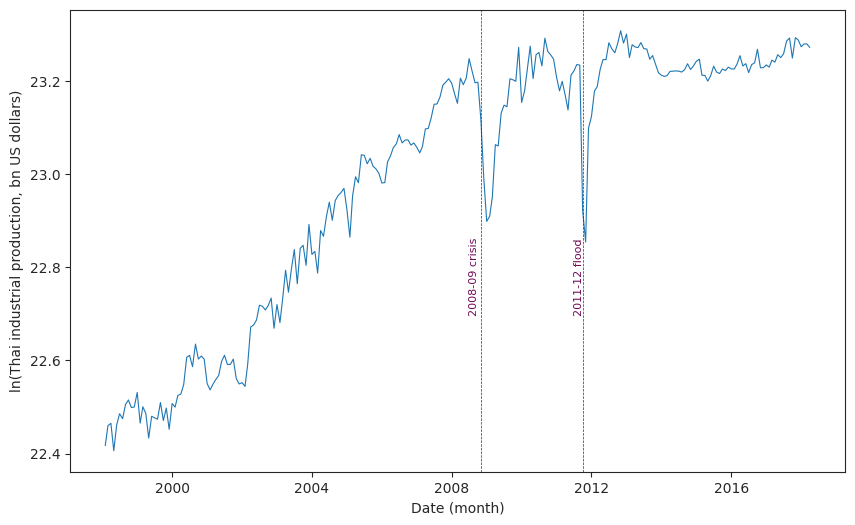

In [38]:
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set the style
plt.style.use('default')  # Use default style instead of 'white'
sns.set_style("ticks")

# Define colors (since color[0] and color[2] are used in the original code)
colors = ['#1f77b4', '#ff7f0e', "#700859"]  # standard matplotlib colors

# Create figure and plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data
thai_data = work.loc[work["country"] == "Thailand"].reset_index()
ax.plot(thai_data["date"], thai_data["ln_ip"], color=colors[0], linewidth=0.8)

# Add vertical lines for events
crisis_date = dt.strptime("2008-11-01", "%Y-%m-%d")
flood_date = dt.strptime("2011-10-01", "%Y-%m-%d")
ax.axvline(x=crisis_date, linestyle='dashed', color=colors[2], linewidth=0.5)
ax.axvline(x=flood_date, linestyle='dashed', color=colors[2], linewidth=0.5)

# Add annotations
ax.text(dt.strptime("2008-07-01", "%Y-%m-%d"), 22.7, "2008-09 crisis", 
    rotation=90, color=colors[2], fontsize=8)
ax.text(dt.strptime("2011-07-01", "%Y-%m-%d"), 22.7, "2011-12 flood", 
    rotation=90, color=colors[2], fontsize=8)

# Set axis labels
ax.set_xlabel('Date (month)')
ax.set_ylabel('ln(Thai industrial production, bn US dollars)')

# Set y-ticks
ax.set_yticks(range(int(22.4), int(23.5), int(0.2)))

# Set x-ticks
date_breaks = ["1998-01-01", "2002-01-01", "2006-01-01", "2010-01-01", "2014-01-01", "2018-01-01"]
date_breaks = [dt.strptime(d, "%Y-%m-%d") for d in date_breaks]
ax.set_xticks(date_breaks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%Y'))

# Layout improvements
plt.tight_layout()
sns.despine()

plt.show()


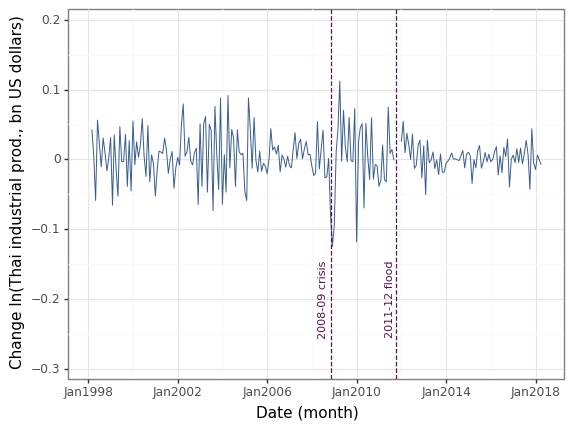

<ggplot: (676487629)>

In [26]:
(
    ggplot(
        work.loc[work["country"] == "Thailand"].reset_index(), aes(x="date", y="dln_ip")
    )
    + geom_line(color=color[0], size=0.4)
    + scale_y_continuous(
        expand=(0.01, 0.01), limits=(-0.3, 0.2), breaks=seq(-0.3, 0.2, 0.1)
    )
    + theme_bw()
    + xlab("Date (month)")
    + ylab("Change ln(Thai industrial prod., bn US dollars)")
    + geom_vline(
        xintercept=dt.strptime("2008-11-01", "%Y-%m-%d"),
        linetype="dashed",
        color=color[2],
        size=0.5,
    )
    + annotate(
        "text",
        size=8,
        color=color[2],
        label="2008-09 crisis",
        y=-0.2,
        x=dt.strptime("2008-07-01", "%Y-%m-%d"),
        angle=90,
    )
    + geom_vline(
        xintercept=dt.strptime("2011-10-01", "%Y-%m-%d"),
        linetype="dashed",
        color=color[2],
        size=0.5,
    )
    + annotate(
        "text",
        size=8,
        color=color[2],
        label="2011-12 flood",
        y=-0.2,
        x=dt.strptime("2011-07-01", "%Y-%m-%d"),
        angle=90,
    )
    + scale_x_date(
        breaks=[
            "1998-01-01",
            "2002-01-01",
            "2006-01-01",
            "2010-01-01",
            "2014-01-01",
            "2018-01-01",
        ],
        labels=date_format("%b%Y"),
    )
)

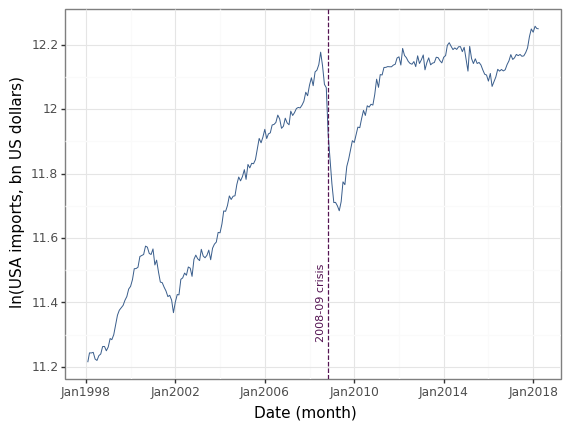

<ggplot: (676517090)>

In [27]:
(
    ggplot(work.reset_index(), aes(x="date", y="ln_usa_imports"))
    + geom_line(color=color[0], size=0.4)
    + theme_bw()
    + xlab("Date (month)")
    + ylab("ln(USA imports, bn US dollars)")
    + scale_y_continuous(breaks=seq(11.2, 12.2, 0.2))
    + scale_x_date(
        breaks=[
            "1998-01-01",
            "2002-01-01",
            "2006-01-01",
            "2010-01-01",
            "2014-01-01",
            "2018-01-01",
        ],
        labels=date_format("%b%Y"),
    )
    + geom_vline(
        xintercept=work.loc[work["date"] == "2008-11-01", "date"].values[0],
        linetype="dashed",
        color=color[2],
        size=0.5,
    )
    + annotate(
        "text",
        size=8,
        color=color[2],
        label="2008-09 crisis",
        y=11.4,
        x=work.loc[work["date"] == "2008-07-01", "date"].values[0],
        angle=90,
    )
)

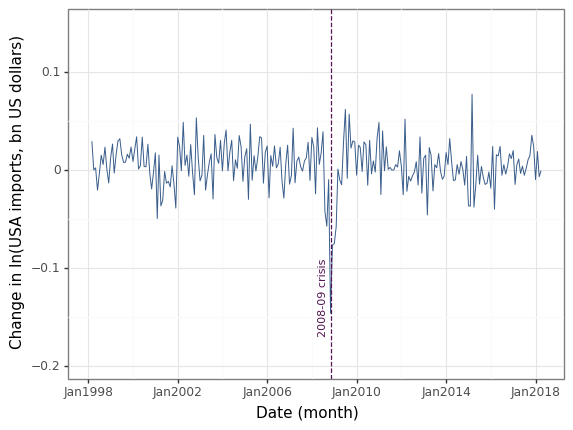

<ggplot: (676487915)>

In [28]:
(
    ggplot(work.reset_index(), aes(x="date", y="dln_usa_imports"))
    + geom_line(color=color[0], size=0.4)
    + scale_y_continuous(
        expand=(0.01, 0.01), limits=(-0.2, 0.15), breaks=np.arange(-0.2, 0.16, 0.1)
    )
    + scale_x_date(
        breaks=[
            "1998-01-01",
            "2002-01-01",
            "2006-01-01",
            "2010-01-01",
            "2014-01-01",
            "2018-01-01",
        ],
        labels=date_format("%b%Y"),
    )
    + theme_bw()
    + xlab("Date (month)")
    + ylab("Change in ln(USA imports, bn US dollars)")
    + geom_vline(
        xintercept=work.loc[work["date"] == "2008-11-01", "date"].values[0],
        linetype="dashed",
        color=color[2],
        size=0.5,
    )
    + annotate(
        "text",
        size=8,
        color=color[2],
        label="2008-09 crisis",
        y=-0.13,
        x=work.loc[work["date"] == "2008-07-01", "date"].values[0],
        angle=90,
    )
)

In [29]:
# REGRESSIONS

# Serial correlation matters because it may lead to biased standard error estimates.
# We recommended two ways to address this problem: estimate Newey–West standard errors
# or include the lag of the dependent variable in the regression. (Used here.)


In [30]:
lags_usa = " + ".join(["dln_usa_imports.shift({i})".format(i=i) for i in range(0, 5)])
lags_ip = " + ".join(["dln_ip.shift({i})".format(i=i) for i in range(1, 3)])

thai_formula = "dln_ip ~ " + lags_usa + " + " + lags_ip


In [31]:
smf.ols(thai_formula, work.loc[lambda x: x["countrycode"] == "THA"]).fit().summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 dln_ip   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     3.470
Date:                Sat, 08 Oct 2022   Prob (F-statistic):            0.00149
Time:                        12:02:01   Log-Likelihood:                 424.62
No. Observations:                 238   AIC:                            -833.2
Df Residuals:                     230   BIC:                            -805.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.0024      0.003      0.849      0.397      -0.003       0.008
dln_usa_imports.shift(0)     0.3430      0.121      2.846      0.005       0.106       0.580
dln_usa_imports.shift(1)     0.2805      0.122      2.301      0.022       0.040       0.521
dln_usa_imports.shift(2)     0.1851      0.115      1.603      0.110      -0.042       0.412
dln_usa_imports.shift(3)    -0.1226      0.120     -1.020      0.309      -0.359       0.114
dln_usa_imports.shift(4)    -0.1940      0.120     -1.620      0.107      -0.430       0.042
dln_ip.shift(1)             -0.1383      0.065     -2.142      0.033      -0.265      -0.011
dln_ip.shift(2)             -0.1630      0.064     -2.537      0.012      -0.290      -0.036
==============================================================================
Omnibus:                      130.425   Durbin-Watson:                   2.032
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2412.659
Skew:                          -1.692   Prob(JB):                         0.00
Kurtosis:                      18.226   Cond. No.                         54.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
# long-term coeff, lagged dy, countries separately
lags_usa = " + ".join(
    ["dln_usa_imports.shift({i}).diff()".format(i=i) for i in range(0, 4)]
)
lt_formula = "dln_ip ~ dln_usa_imports.shift(4) + " + lags_usa + "+ dln_ip.shift(1)"


In [33]:
tha_reg_lt = smf.ols(lt_formula, work.loc[lambda x: x["countrycode"] == "THA"]).fit(
    cov_type="HC0"
)
mys_reg_lt = smf.ols(lt_formula, work.loc[lambda x: x["countrycode"] == "MYS"]).fit(
    cov_type="HC0"
)
phl_reg_lt = smf.ols(lt_formula, work.loc[lambda x: x["countrycode"] == "PHL"]).fit(
    cov_type="HC0"
)
sgp_reg_lt = smf.ols(lt_formula, work.loc[lambda x: x["countrycode"] == "SGP"]).fit(
    cov_type="HC0"
)


In [34]:
# long-term coeff, lagged dy, countries pooled
lt_formula_pooled = (
    "dln_ip ~ dln_usa_imports.shift(4) + " + lags_usa + " + dln_ip.shift(1) + cc"
)
pooled_reg_lt = smf.ols(lt_formula_pooled, work).fit(cov_type="HC0")


In [35]:
models = [tha_reg_lt, mys_reg_lt, phl_reg_lt, sgp_reg_lt, pooled_reg_lt]
names = ["Thailand", "Malaysia", "Philippines", "Singapore", "Pooled"]
stargazer = Stargazer(models)
stargazer.rename_covariates(
    {
        "Intercept": "Constant",
        "dln_usa_imports.shift(4)": "USA imports log change, cumulative coeff.",
        "dln_ip.shift(1)": "Industrial production log change, lag",
        "cc[T.PHL]": "Philippines",
        "cc[T.SGP]": "Singapore",
        "cc[T.THA]": "Thailand",
    }
)
stargazer.covariate_order(
    [
        "dln_usa_imports.shift(4)",
        "dln_ip.shift(1)",
        "cc[T.SGP]",
        "cc[T.PHL]",
        "cc[T.THA]",
        "Intercept",
    ]
)
stargazer.custom_columns(names, [1, 1, 1, 1, 1])
HTML(stargazer.render_html())
